## Dataset Paths 

In [1]:
from pathlib import Path

DATA_ROOT = Path("/kaggle/input/datasets/enjyashraf18/imu-dataset")
WORK_ROOT = Path(r"/kaggle/working/imu_terrain_outputs")
WORK_ROOT.mkdir(parents=True, exist_ok=True)
FIG_DIR    = WORK_ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Dataset

In [2]:
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import time, gc, json, os

from scipy.signal import butter, filtfilt
from scipy.stats import skew, kurtosis, iqr
from scipy.fft import rfft, rfftfreq

FS = 100
MIN_STRIDE_SAMPLES = 40
MAX_STRIDE_SAMPLES = 220
TURN_IS_NONZERO = True
TERRAIN_PURITY_THRESH= 0.80

LOWPASS_CUTOFF          = 20.0
FILTER_ORDER            = 4
"""
Why does it exist? (The problem it solves)
In the dataset, the Terrain column is recorded every single row (every 0.01 second because sampling rate is 100 Hz).
But in real life, when a person is walking:

One stride (one step) should mostly be on one type of terrain.
Sometimes the label changes in the middle of a stride (because the person is stepping from flat ground onto grass, or starting to climb stairs, etc.).

If the terrain label is jumping around a lot inside the same stride, then that stride is confusing — we don’t really know what terrain it belongs to.
So the notebook adds a purity check to only keep clean, trustworthy strides.
"""

PRIMARY_SENSOR = "PS"
ALL_SENSORS = ("PS", "TH", "TR", "OS", "OH")
SIGNAL_COLUMNS = (
    "Acc_X", "Acc_Y", "Acc_Z",
    "FreeAcc_E", "FreeAcc_N", "FreeAcc_U",
    "Gyr_X", "Gyr_Y", "Gyr_Z",
)
OPTIONAL_COLS = ("Mag_X", "Mag_Y", "Mag_Z", "VelInc_X", "VelInc_Y", "VelInc_Z")
LABEL_COLS    = ("Steps", "Terrain", "Turn")

TERRAIN_LABELS = {
    1: "Flat",
    2: "Grass",
    4: "Stair Ascent",
    5: "Stair Descent",
    6: "Slope Ascent",
    7: "Slope Descent",
    8: "Gravel",
    9: "Uneven Terrain",
}

MERGE_STAIRS = True 
TERRAIN_NAMES = TERRAIN_LABELS.copy()

## Signal Preprocessing

### Hampel Filter
It takes a 1D array of numbers (x) and two optional settings (window size and how strict it is).

**Why?** IMU sensors sometimes get sudden spikes (outliers) from tiny bumps, electrical noise, or the prosthesis hitting something. These spikes mess up later calculations.

#### How it works
1. Looks at a small window of 11 samples around the current one (5 before + current + 5 after).
2. Finds the median of that window.
3. If the current point is way farther from the median than normal (more than 3× the robust sigma), replace it with the median.

In [3]:
# building Butterworth filter once
_b, _a = butter(FILTER_ORDER, LOWPASS_CUTOFF / (FS / 2.0), btype="low")

def hampel_filter(x: np.ndarray, half_window: int = 5, sigma: float = 3.0) -> np.ndarray:
    x = x.copy().astype(float)
    n = len(x)
    for i in range(n):
        lo = max(0, i - half_window)
        hi = min(n, i + half_window + 1)
        window = x[lo:hi]
        med = np.median(window)
        mad = np.median(np.abs(window - med))
        if mad == 0:
            continue
        if abs(x[i] - med) > sigma * 1.4826 * mad:
            x[i] = med
    return x

# loads one CSV file (one sensor) and cleans it
def load_sensor_csv(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    # Convert all important columns to numbers (just in case)
    all_numeric = SIGNAL_COLUMNS + OPTIONAL_COLS + LABEL_COLS
    for col in all_numeric:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # fill missing values (interpolation)
    cont_cols = [c for c in SIGNAL_COLUMNS + OPTIONAL_COLS if c in df.columns]
    for col in cont_cols:
        if df[col].isna().any():
            df[col] = (df[col].interpolate(limit_direction="both").ffill().bfill())

    # butterworth low pass filter 
    if len(df) >= 3 * FILTER_ORDER and cont_cols:
        for col in cont_cols:
            vals = df[col].to_numpy(dtype=float)
            if np.isfinite(vals).all() and np.std(vals) > 1e-9:
                df[col] = filtfilt(_b, _a, vals)

    # hampel filter
    for col in cont_cols:
        if col in df.columns:
            df[col] = hampel_filter(df[col].to_numpy())

    # create magn (overall intensity) for each sensor type
    for prefix, axes in [
        ("Acc",     ("Acc_X",     "Acc_Y",     "Acc_Z")),
        ("FreeAcc", ("FreeAcc_E", "FreeAcc_N", "FreeAcc_U")),
        ("Gyr",     ("Gyr_X",     "Gyr_Y",     "Gyr_Z")),
        ("Mag",     ("Mag_X",     "Mag_Y",     "Mag_Z")),
        ("VelInc",  ("VelInc_X",  "VelInc_Y",  "VelInc_Z")),]:
        if all(a in df.columns for a in axes):
            arr = df[list(axes)].to_numpy(dtype=float)
            df[f"{prefix}_MAG"] = np.sqrt((arr ** 2).sum(axis=1))

    return df

## Feature Extraction (per stride)

### Spectral Entropy

Measures how “spread out” the frequencies are.

1. Flat walking → very regular → low entropy.

2. Grass/uneven → chaotic → higher entropy.



### Dominant Freq

Finds the strongest frequency in the signal 

Stairs often have higher dominant frequency than flat ground.

### freq band energy 
What percentage of the total movement energy is happening in the low, medium, and high frequency ranges?
Why is this useful for terrain classification?

1. Flat ground: Most energy in low frequencies (very regular walking).
2. Grass / Gravel / Uneven: Much more energy in higher frequencies (because the foot is shaking and bouncing irregularly).
3. Stairs / Slopes: Different pattern / often more energy in medium frequencies.

So these 3 features (band_0_2, band_2_5, band_5_20) act like a signature of the terrain type.

In [4]:
def spectral_entropy(x: np.ndarray) -> float:
    centered = x - x.mean()
    power = np.abs(rfft(centered)) ** 2
    power = power[1:]   # drop DC
    total = power.sum()
    if total <= 0:
        return 0.0
    p = power / total
    return float(-(p * np.log(p + 1e-12)).sum())


def dominant_freq(x: np.ndarray) -> float:
    centered = x - x.mean()
    spectrum = np.abs(rfft(centered))
    if len(spectrum) <= 1:
        return 0.0
    freqs = rfftfreq(len(centered), d=1.0 / FS)
    idx = int(np.argmax(spectrum[1:]) + 1)
    return float(freqs[idx])

def freq_band_energy(x: np.ndarray, lo: float, hi: float) -> float:
    centered = x - x.mean()
    power = np.abs(rfft(centered)) ** 2
    freqs = rfftfreq(len(centered), d=1.0 / FS)
    total = power.sum()
    if total <= 0:
        return 0.0
    mask = (freqs >= lo) & (freqs < hi)
    return float(power[mask].sum() / total)

"""
For any signal (Acc_X, Gyr_MAG, etc.), it calculates many statistics:
mean, std, min, max, median, iqr, rms, energy
skew, kurtosis (shape of distribution)
percentiles (p10, p90)
start, end, delta (how it changes during stride)
dominant frequency + spectral entropy
"""
def summarize_signal(values: np.ndarray, prefix: str) -> dict:
    nan_row = {f"{prefix}__{n}": np.nan for n in (
        "mean", "std", "min", "max", "median", "iqr", "rms", "energy",
        "skew", "kurtosis", "p10", "p90", "range",
        "start", "end", "delta","dom_freq", "spec_entropy","band_0_2", "band_2_5", "band_5_20",)}

    values = np.asarray(values, dtype=float)
    if values.size == 0 or not np.isfinite(values).any():
        return nan_row

    std_val = float(np.std(values))

    feat = {
        f"{prefix}__mean"    : float(np.mean(values)),
        f"{prefix}__std"     : std_val,
        f"{prefix}__min"     : float(np.min(values)),
        f"{prefix}__max"     : float(np.max(values)),
        f"{prefix}__median"  : float(np.median(values)),
        f"{prefix}__iqr"     : float(iqr(values)),
        f"{prefix}__rms"     : float(np.sqrt(np.mean(values ** 2))),
        f"{prefix}__energy"  : float(np.mean(values ** 2)),
        f"{prefix}__skew"    : float(skew(values, bias=False))   if (len(values) > 2 and std_val > 1e-9) else 0.0,
        f"{prefix}__kurtosis": float(kurtosis(values, bias=False)) if (len(values) > 3 and std_val > 1e-9) else 0.0,
        f"{prefix}__p10"     : float(np.percentile(values, 10)),
        f"{prefix}__p90"     : float(np.percentile(values, 90)),
        f"{prefix}__range"   : float(np.max(values) - np.min(values)),
        f"{prefix}__start"   : float(values[0]),
        f"{prefix}__end"     : float(values[-1]),
        f"{prefix}__delta"   : float(values[-1] - values[0]),
        f"{prefix}__dom_freq": dominant_freq(values),
        f"{prefix}__spec_entropy": spectral_entropy(values),
        # Frequency band energy ratios (walking gait lives 0-5 Hz; stairs/slopes higher)
        f"{prefix}__band_0_2" : freq_band_energy(values, 0.0,  2.0),
        f"{prefix}__band_2_5" : freq_band_energy(values, 2.0,  5.0),
        f"{prefix}__band_5_20": freq_band_energy(values, 5.0, 20.0),
    }
    return feat
# adding the calculated mag
FEATURE_SIGNALS = SIGNAL_COLUMNS + ("Acc_MAG", "FreeAcc_MAG", "Gyr_MAG",)
print(f"Feature signals: {len(FEATURE_SIGNALS)} × sensors × ~22 stats")

Feature signals: 12 × sensors × ~22 stats


## Stride Segmentation & Trial Processing

### Safe Mode
Finds the most common value in a col.

**Why? ** Inside one stride, the Terrain label might have a few different numbers due to noise or transition --> we want the most frequent terrain label for that stride

In [5]:
def safe_mode(s: pd.Series):
    clean = s.dropna()
    if clean.empty:
        return np.nan
    m = clean.mode()
    return m.iloc[0] if not m.empty else clean.iloc[0]


# Split filename into trial base name and sensor code GRwi01PS' → ('GRwi01', 'PS')
def split_trial_stem(stem: str):
    upper = stem.upper()
    for sensor in sorted(ALL_SENSORS, key=len, reverse=True):
        if upper.endswith(sensor):
            return stem[: -len(sensor)], sensor
    return None, None


"""
reads all csv files in a participant’s folder and groups them by trial
example: {
'trial_id': 'FLwi01', 
'sensor_paths': {'OS': PosixPath, 'PS': PosixPath, 'TH': PosixPath, 'TR': PosixPath}}
"""
def collect_trial_groups(csv_root: Path) -> list[dict]:
    grouped = defaultdict(dict)
    for csv_path in sorted(csv_root.glob("*.csv")):
        base, sensor = split_trial_stem(csv_path.stem)
        if sensor is None:
            continue
        grouped[base][sensor] = csv_path
    return [{"trial_id": tid, "sensor_paths": spaths}
        for tid, spaths in sorted(grouped.items())
        if "PS" in spaths]


### build stride features

Creates basic features about the stride itself

How many samples long it is, Duration (normal walking stride ≈ 0.8–1.2 seconds), Step frequency 

### extract_trial_stride_records(...) — The master function
This is the main function that processes one complete trial.

1. Loads all sensor CSVs for that trial.
2. Makes sure all sensors have the same length (aligns them).
3. Uses the PS sensor (prosthetic shank) as reference because it has the Steps, Terrain, and Turn labels.
4. Loops through every stride (group of rows with same Steps number).
5. Applies several quality filters:
    - Stride must be between 40 and 220 samples long (reasonable step time)
    - Terrain label must be consistent inside the stride (≥80% the same)
    - Skip turning strides

For each good stride, it builds all the features


In [6]:
def build_stride_features(sensor_frames: dict, stride_idx: np.ndarray) -> dict:
    n = len(stride_idx)
    feats = {
        "stride_samples"    : n,
        "stride_duration_s" : n / FS,
        "stride_freq_hz"    : FS / n if n else np.nan,}
    for sensor in ALL_SENSORS:
        frame = sensor_frames.get(sensor)
        for sig in FEATURE_SIGNALS:
            key = f"{sensor}__{sig}"
            if frame is None or sig not in frame.columns:
                feats.update(summarize_signal(np.array([]), key))
                continue
            valid = stride_idx[(stride_idx >= 0) & (stride_idx < len(frame))]
            vals  = frame[sig].iloc[valid].to_numpy(dtype=float) if len(valid) else np.array([])
            feats.update(summarize_signal(vals, key))
    return feats


def extract_trial_stride_records(participant_id: str, trial_id: str,sensor_paths: dict) -> list[dict]:
    # load and align all sensors
    frames = {s: load_sensor_csv(p) for s, p in sensor_paths.items()}
    min_len = min(len(df) for df in frames.values())
    frames  = {s: df.iloc[:min_len].reset_index(drop=True) for s, df in frames.items()}

    ref = frames[PRIMARY_SENSOR].copy()
    for col in LABEL_COLS:
        if col not in ref.columns:
            return []
    ref["Steps"]   = pd.to_numeric(ref["Steps"],   errors="coerce")
    ref["Terrain"] = pd.to_numeric(ref["Terrain"], errors="coerce")
    ref["Turn"]    = pd.to_numeric(ref["Turn"],    errors="coerce").fillna(0)

    valid_ref = ref.loc[ref["Steps"].notna() & (ref["Steps"] > 0)]
    if valid_ref.empty:
        return []

    records = []
    for step_id, g in valid_ref.groupby("Steps", sort=True):
        idx = g.index.to_numpy(dtype=int)
        if not (MIN_STRIDE_SAMPLES <= len(idx) <= MAX_STRIDE_SAMPLES):
            continue

        terrain_s = g["Terrain"].dropna().astype(int)
        if terrain_s.empty:
            continue
        t_mode  = int(safe_mode(terrain_s))
        t_purity = float((terrain_s == t_mode).mean())
        if t_mode not in TERRAIN_LABELS or t_purity < TERRAIN_PURITY_THRESH:
            continue

        # drop turning strides
        if (g["Turn"] != 0).any():
            continue

        rec = {
            "participant_id" : participant_id,
            "trial_id"       : trial_id,
            "step_id"        : int(step_id),
            "terrain_code"   : t_mode,
            "terrain_name"   : TERRAIN_LABELS[t_mode],
            "terrain_purity" : t_purity,
        }
        rec.update(build_stride_features(frames, idx))
        records.append(rec)

    return records

In [7]:
CACHE_FILE = WORK_ROOT / "features_cache.parquet"

def discover_participants(root: Path) -> list[Path]:
    root = root.expanduser().resolve()

    participants = []
    for child in sorted(root.iterdir()):
        if child.is_dir():
            participants.append(child)

    return participants


def build_dataset(force_rebuild: bool = False) -> pd.DataFrame:
    if CACHE_FILE.exists() and not force_rebuild:
        print(f"Loading cached features from {CACHE_FILE}")
        df = pd.read_parquet(CACHE_FILE)
        print(f"  → {len(df):,} strides, {df.shape[1]} columns")
        return df

    all_records = []
    p_dirs = discover_participants(DATA_ROOT)
    t0 = time.time()

    for p_dir in p_dirs:
        pid = p_dir.name
        trials = collect_trial_groups(p_dir)
        p_records = []
        for t in trials:
            try:
                recs = extract_trial_stride_records(pid, t["trial_id"], t["sensor_paths"])
                p_records.extend(recs)
            except Exception as e:
                print(f"  ✗ {pid}/{t['trial_id']}: {e}")

        print(f"  {pid}: {len(trials)} trials → {len(p_records)} strides")
        all_records.extend(p_records)

    df = pd.DataFrame(all_records)
    df.to_parquet(CACHE_FILE, index=False)
    print(f"\nTotal: {len(df):,} strides | {df.shape[1]} features | {time.time()-t0:.1f}s")
    return df


df_raw = build_dataset(force_rebuild=True)
df_raw["terrain_name"].value_counts()

  P1: 47 trials → 745 strides
  P10: 50 trials → 668 strides
  P11: 54 trials → 790 strides
  P12: 48 trials → 612 strides
  P13: 12 trials → 107 strides
  P14: 9 trials → 223 strides
  P15: 14 trials → 126 strides
  P16: 5 trials → 110 strides
  P17: 7 trials → 191 strides
  P18: 3 trials → 104 strides
  P19: 9 trials → 189 strides
  P2: 43 trials → 490 strides
  P20: 7 trials → 179 strides
  P3: 38 trials → 367 strides
  P4: 12 trials → 417 strides
  P5: 35 trials → 200 strides
  P6: 56 trials → 871 strides
  P7_TF: 49 trials → 594 strides
  P7_TT: 48 trials → 617 strides
  P8: 39 trials → 461 strides
  P9: 53 trials → 786 strides

Total: 8,847 strides | 1269 features | 4461.5s


terrain_name
Flat              2292
Gravel            1433
Slope Descent     1038
Grass              959
Slope Ascent       930
Uneven Terrain     877
Stair Descent      681
Stair Ascent       637
Name: count, dtype: int64

## Data Analysis

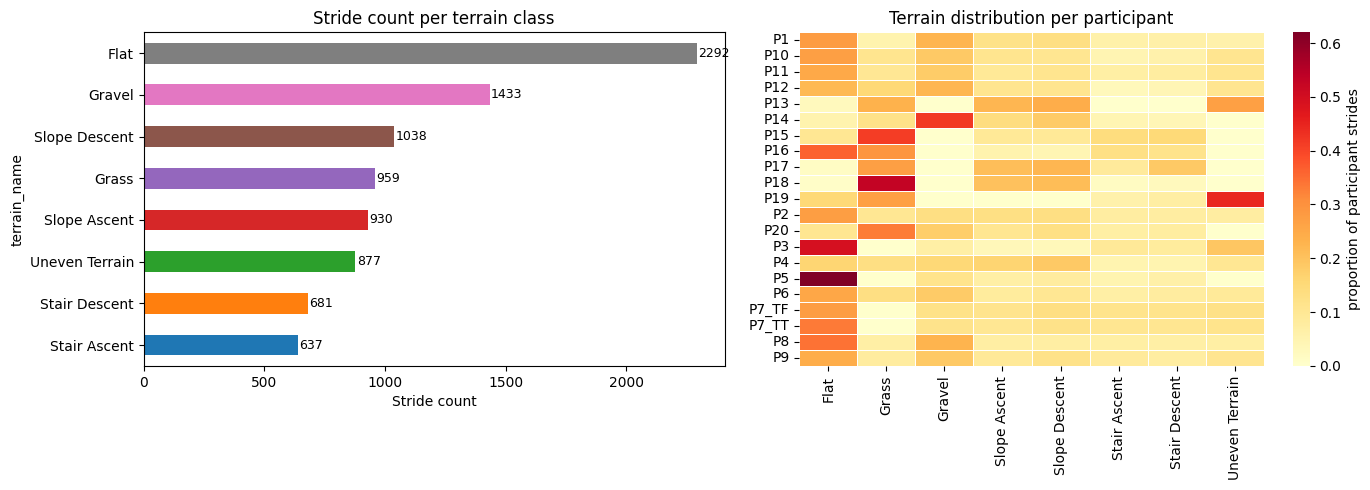

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df_raw["terrain_name"].value_counts().sort_values(ascending=True)
ax = axes[0]
counts.plot.barh(ax=ax, color=sns.color_palette("tab10", len(counts)))
ax.set_xlabel("Stride count")
ax.set_title("Stride count per terrain class")
for i, v in enumerate(counts.values):
    ax.text(v + 5, i, str(v), va="center", fontsize=9)

# Participants × terrains heatmap
pivot = df_raw.groupby(["participant_id", "terrain_name"]).size().unstack(fill_value=0)
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)
sns.heatmap(pivot_norm, ax=axes[1], cmap="YlOrRd", linewidths=0.4,
            cbar_kws={"label": "proportion of participant strides"})
axes[1].set_title("Terrain distribution per participant")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(FIG_DIR / "01_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Prepare Features & Labels

In [9]:
def apply_stair_merge(y: np.ndarray) -> tuple[np.ndarray, dict]:
    if not MERGE_STAIRS:
        return y, TERRAIN_NAMES.copy()
    y_new = y.copy()
    # merge descent into ascent code
    y_new[y_new == 5] = 4          
    merged_names = {k: v for k, v in TERRAIN_NAMES.items() if k != 5}
    merged_names[4] = "Stairs"    
    return y_new, merged_names

In [10]:
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

META_COLS = ["participant_id", "trial_id", "step_id","terrain_code", "terrain_name", "terrain_purity"]

# All the real features (PS__Acc_X__mean, TR__Gyr_MAG__std, ... )
feat_cols = [c for c in df_raw.columns if c not in META_COLS]

X_raw = df_raw[feat_cols].copy()
y_raw = df_raw["terrain_code"].values
groups = df_raw["participant_id"].values   

y_raw_merged, active_terrain_names = apply_stair_merge(y_raw)

# encode labels → 0-based integer
le = LabelEncoder()
y = le.fit_transform(y_raw_merged)
class_names = [active_terrain_names[c] for c in le.classes_]

print(f"Feature matrix : {X_raw.shape}")

Feature matrix : (8847, 1263)


Some features might have missing values (NaN), so SimpleImputer fills them with median value 



RobustScaler()

Scales all features so they are in similar ranges.

In [11]:
preprocessor = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  RobustScaler()),
])

X = preprocessor.fit_transform(X_raw)
print(f"any NaN after impute?? {np.isnan(X).any()}")

any NaN after impute?? False


## Model Training 

In [12]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, balanced_accuracy_score,
    f1_score, ConfusionMatrixDisplay)

import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight

In [13]:
uniq_participants = np.unique(groups)
n_participants    = len(uniq_participants)
group_ids         = np.array([np.where(uniq_participants == g)[0][0] for g in groups])

print(f"participants : {n_participants}")

try:
    _test = xgb.XGBClassifier(device="cuda", n_estimators=2, verbosity=0)
    _test.fit(X[:10], y[:10])
    XGB_DEVICE = "cuda"
    print("XGBoost GPU (cuda) available ✓")
except Exception:
    XGB_DEVICE = "cpu"
    print("XGBoost running on CPU")

# class weights to handle imbalance (Flat >> Gravel)
sample_weights = compute_sample_weight("balanced", y)

xgb_params = dict(
    n_estimators      = 800,
    max_depth         = 7,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.7,
    min_child_weight  = 3,
    gamma             = 0.1,
    reg_alpha         = 0.5,      
    reg_lambda        = 1.5,      
    use_label_encoder = False,
    eval_metric       = "mlogloss",
    tree_method       = "hist",
    device            = XGB_DEVICE,
    n_jobs            = -1,
    random_state      = 42,
    verbosity         = 0,
)

participants : 21
XGBoost GPU (cuda) available ✓


  Fold  1 | n= 1036 | Acc=0.5772 | BalAcc=0.5240 | MacroF1=0.5111 | WtF1=0.5478
  Fold  2 | n=  855 | Acc=0.5450 | BalAcc=0.5461 | MacroF1=0.5185 | WtF1=0.5242
  Fold  3 | n= 1115 | Acc=0.4332 | BalAcc=0.4016 | MacroF1=0.3675 | WtF1=0.3885
  Fold  4 | n=  871 | Acc=0.5626 | BalAcc=0.5687 | MacroF1=0.5223 | WtF1=0.4838
  Fold  5 | n=  808 | Acc=0.6757 | BalAcc=0.6350 | MacroF1=0.6237 | WtF1=0.6851
  Fold  6 | n=  873 | Acc=0.4845 | BalAcc=0.4912 | MacroF1=0.4751 | WtF1=0.4881
  Fold  7 | n=  893 | Acc=0.5577 | BalAcc=0.5153 | MacroF1=0.5232 | WtF1=0.5362
  Fold  8 | n=  790 | Acc=0.5924 | BalAcc=0.5907 | MacroF1=0.5259 | WtF1=0.5427
  Fold  9 | n=  794 | Acc=0.6725 | BalAcc=0.6554 | MacroF1=0.6525 | WtF1=0.6628
  Fold 10 | n=  812 | Acc=0.5591 | BalAcc=0.5678 | MacroF1=0.5191 | WtF1=0.5298

──────────────────────────────────────────────────────────────────────
    MEAN |       | Acc=0.5660±0.0738 | BalAcc=0.5496±0.0731 | MacroF1=0.5239±0.0772
  Done in 632.0s


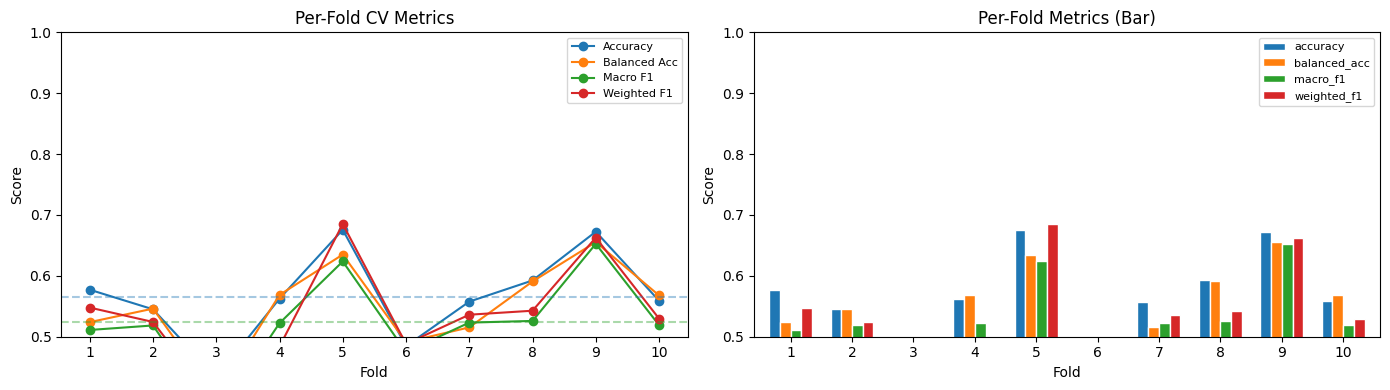

In [14]:
sgkf = StratifiedGroupKFold(n_splits=min(n_participants, 10))

fold_results = []
all_preds = np.zeros(len(y), dtype=int)

t0 = time.time()
for fold_idx, (train_idx, test_idx) in enumerate(sgkf.split(X, y, groups=group_ids)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    sw_train = sample_weights[train_idx]

    fold_clf = xgb.XGBClassifier(**xgb_params)
    fold_clf.fit(X_train, y_train, sample_weight=sw_train)
    fold_preds = fold_clf.predict(X_test)
    all_preds[test_idx] = fold_preds

    fold_acc  = accuracy_score(y_test, fold_preds)
    fold_bacc = balanced_accuracy_score(y_test, fold_preds)
    fold_mf1  = f1_score(y_test, fold_preds, average="macro")
    fold_wf1  = f1_score(y_test, fold_preds, average="weighted")

    fold_results.append({
        "fold": fold_idx + 1,
        "n_test": len(test_idx),
        "accuracy": fold_acc,
        "balanced_acc": fold_bacc,
        "macro_f1": fold_mf1,
        "weighted_f1": fold_wf1,
    })

    print(
        f"  Fold {fold_idx+1:>2} | "
        f"n={len(test_idx):>5} | "
        f"Acc={fold_acc:.4f} | "
        f"BalAcc={fold_bacc:.4f} | "
        f"MacroF1={fold_mf1:.4f} | "
        f"WtF1={fold_wf1:.4f}"
    )

xgb_preds = all_preds
fold_df = pd.DataFrame(fold_results)

print(f"\n{'─'*70}")
print(f"{'MEAN':>8} | {'':>5} | "
      f"Acc={fold_df['accuracy'].mean():.4f}±{fold_df['accuracy'].std():.4f} | "
      f"BalAcc={fold_df['balanced_acc'].mean():.4f}±{fold_df['balanced_acc'].std():.4f} | "
      f"MacroF1={fold_df['macro_f1'].mean():.4f}±{fold_df['macro_f1'].std():.4f}")
print(f"  Done in {time.time()-t0:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

metrics = ["accuracy", "balanced_acc", "macro_f1", "weighted_f1"]
colors  = sns.color_palette("tab10", len(metrics))

ax = axes[0]
x = fold_df["fold"]
for m, c in zip(metrics, colors):
    ax.plot(x, fold_df[m], marker="o", label=m.replace("_", " ").title(), color=c)
ax.axhline(fold_df["accuracy"].mean(),   linestyle="--", color=colors[0], alpha=0.4)
ax.axhline(fold_df["macro_f1"].mean(),   linestyle="--", color=colors[2], alpha=0.4)
ax.set_xlabel("Fold")
ax.set_ylabel("Score")
ax.set_title("Per-Fold CV Metrics")
ax.legend(fontsize=8)
ax.set_ylim(0.5, 1.0)
ax.set_xticks(x)

ax = axes[1]
fold_df.set_index("fold")[["accuracy", "balanced_acc", "macro_f1", "weighted_f1"]].plot(
    kind="bar", ax=ax, color=colors, edgecolor="white", width=0.7)
ax.set_xlabel("Fold")
ax.set_ylabel("Score")
ax.set_title("Per-Fold Metrics (Bar)")
ax.set_xticklabels(fold_df["fold"], rotation=0)
ax.legend(fontsize=8)
ax.set_ylim(0.5, 1.0)

plt.tight_layout()
plt.savefig(WORK_ROOT / "fold_metrics.png", dpi=150, bbox_inches="tight")
plt.show()


## Evaluation and Results

In [15]:
def print_metrics(preds, label="Model"):
    acc  = accuracy_score(y, preds)
    bacc = balanced_accuracy_score(y, preds)
    mf1  = f1_score(y, preds, average="macro")
    wf1  = f1_score(y, preds, average="weighted")
    print(f"{'─'*55}")
    print(f"{label}")
    print(f"  Accuracy          : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Balanced Accuracy : {bacc:.4f}")
    print(f"  Macro F1          : {mf1:.4f}")
    print(f"  Weighted F1       : {wf1:.4f}")
    print()
    return {"model": label, "accuracy": acc, "balanced_acc": bacc,
            "macro_f1": mf1, "weighted_f1": wf1}

results_summary = print_metrics(xgb_preds, "XGBoost")

print("\nPer Class Classification Report")
print("─"*55)
print(classification_report(y, xgb_preds, target_names=class_names, digits=4))


───────────────────────────────────────────────────────
XGBoost
  Accuracy          : 0.5606  (56.06%)
  Balanced Accuracy : 0.5347
  Macro F1          : 0.5340
  Weighted F1       : 0.5466


Per Class Classification Report
───────────────────────────────────────────────────────
                precision    recall  f1-score   support

          Flat     0.5610    0.7046    0.6246      2292
         Grass     0.3442    0.2419    0.2841       959
        Stairs     0.6758    0.8270    0.7438      1318
  Slope Ascent     0.5668    0.4516    0.5027       930
 Slope Descent     0.5000    0.6021    0.5463      1038
        Gravel     0.4635    0.3147    0.3749      1433
Uneven Terrain     0.7350    0.6009    0.6612       877

      accuracy                         0.5606      8847
     macro avg     0.5495    0.5347    0.5340      8847
  weighted avg     0.5495    0.5606    0.5466      8847



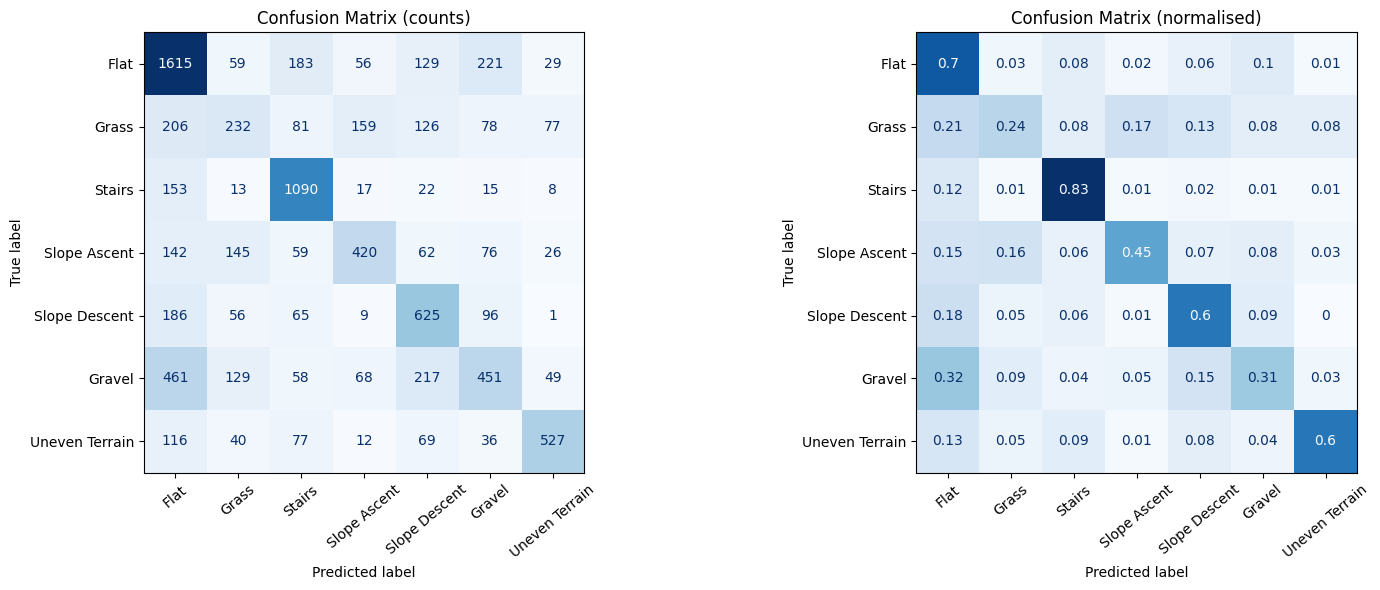

In [16]:
cm = confusion_matrix(y, xgb_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix (counts)")
axes[0].tick_params(axis="x", rotation=40)

# normalised
disp2 = ConfusionMatrixDisplay(confusion_matrix=np.round(cm_norm, 2), display_labels=class_names)
disp2.plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Confusion Matrix (normalised)")
axes[1].tick_params(axis="x", rotation=40)

plt.tight_layout()
plt.savefig(WORK_ROOT / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


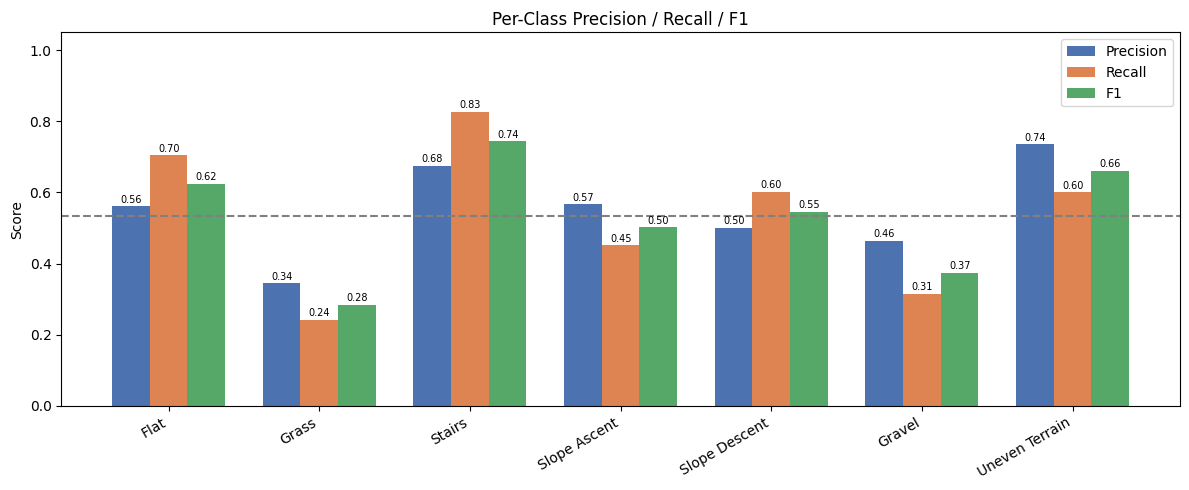

In [17]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1_per_class, support = precision_recall_fscore_support(
    y, xgb_preds, labels=range(len(class_names)))

x = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, precision, width, label="Precision", color="#4C72B0")
ax.bar(x,         recall,    width, label="Recall",    color="#DD8452")
ax.bar(x + width, f1_per_class, width, label="F1",     color="#55A868")
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Per-Class Precision / Recall / F1")
ax.legend()
ax.axhline(np.mean(f1_per_class), linestyle="--", color="grey", label=f"Mean F1={np.mean(f1_per_class):.3f}")
for i, (p, r, f) in enumerate(zip(precision, recall, f1_per_class)):
    ax.text(i - width, p + 0.01, f"{p:.2f}", ha="center", fontsize=7)
    ax.text(i,         r + 0.01, f"{r:.2f}", ha="center", fontsize=7)
    ax.text(i + width, f + 0.01, f"{f:.2f}", ha="center", fontsize=7)
plt.tight_layout()
plt.savefig(WORK_ROOT / "per_class_metrics.png", dpi=150, bbox_inches="tight")
plt.show()


## Feature Importance Analysis

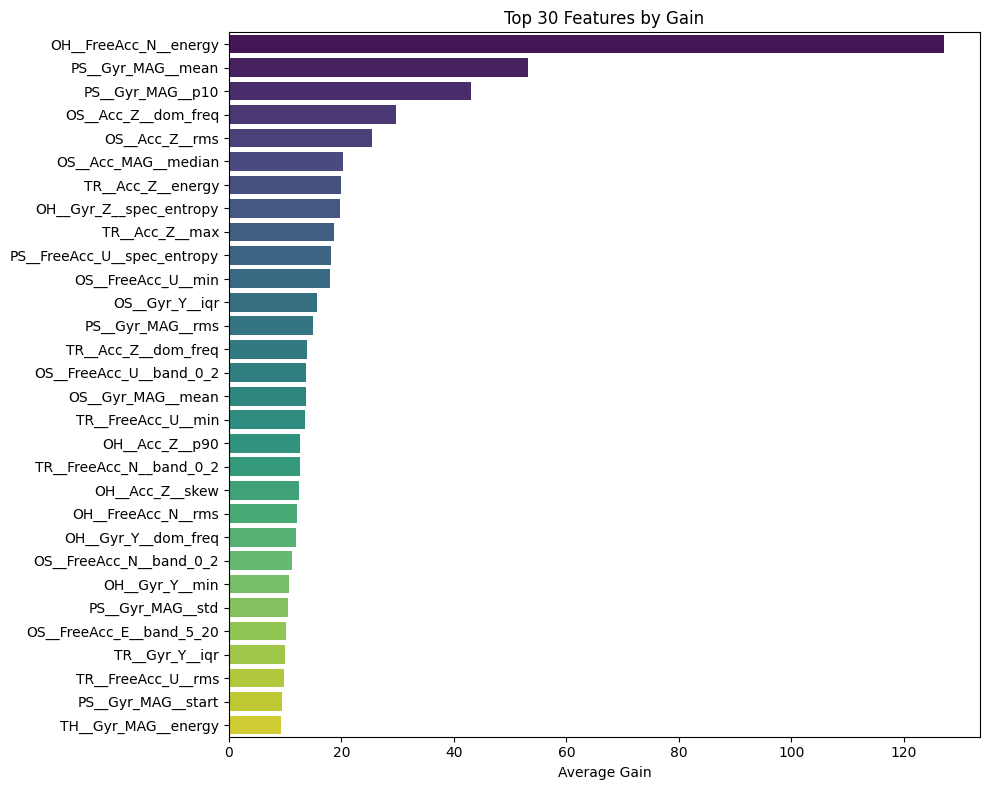

               feature_name  importance
      OH__FreeAcc_N__energy  127.174805
          PS__Gyr_MAG__mean   53.158855
           PS__Gyr_MAG__p10   43.071369
        OS__Acc_Z__dom_freq   29.693535
             OS__Acc_Z__rms   25.500551
        OS__Acc_MAG__median   20.288712
          TR__Acc_Z__energy   19.841661
    OH__Gyr_Z__spec_entropy   19.688742
             TR__Acc_Z__max   18.720156
PS__FreeAcc_U__spec_entropy   18.218317
         OS__FreeAcc_U__min   17.951536
             OS__Gyr_Y__iqr   15.647171
           PS__Gyr_MAG__rms   15.027494
        TR__Acc_Z__dom_freq   13.903321
    OS__FreeAcc_U__band_0_2   13.742675
          OS__Gyr_MAG__mean   13.626279
         TR__FreeAcc_U__min   13.591586
             OH__Acc_Z__p90   12.699142
    TR__FreeAcc_N__band_0_2   12.545596
            OH__Acc_Z__skew   12.408229
         OH__FreeAcc_N__rms   12.020996
        OH__Gyr_Y__dom_freq   11.969181
    OS__FreeAcc_N__band_0_2   11.215353
             OH__Gyr_Y__min   10.586423


In [18]:
final_clf = xgb.XGBClassifier(**xgb_params)
final_clf.fit(X, y, sample_weight=sample_weights)

importance_types = ["weight", "gain", "cover"]
fi_dfs = {}
for imp_type in importance_types:
    scores = final_clf.get_booster().get_score(importance_type=imp_type)
    fi_df  = pd.DataFrame(scores.items(), columns=["feature_idx", "importance"])
    fi_df["feature_name"] = fi_df["feature_idx"].apply(
        lambda s: feat_cols[int(s[1:])] if s.startswith("f") and s[1:].isdigit() else s)
    fi_df = fi_df.sort_values("importance", ascending=False).reset_index(drop=True)
    fi_dfs[imp_type] = fi_df

top_n = 30
fi_gain = fi_dfs["gain"].head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=fi_gain, y="feature_name", x="importance", palette="viridis", ax=ax)
ax.set_title(f"Top {top_n} Features by Gain")
ax.set_xlabel("Average Gain")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(WORK_ROOT / "feature_importance_gain.png", dpi=150, bbox_inches="tight")
plt.show()
print(fi_gain[["feature_name", "importance"]].to_string(index=False))


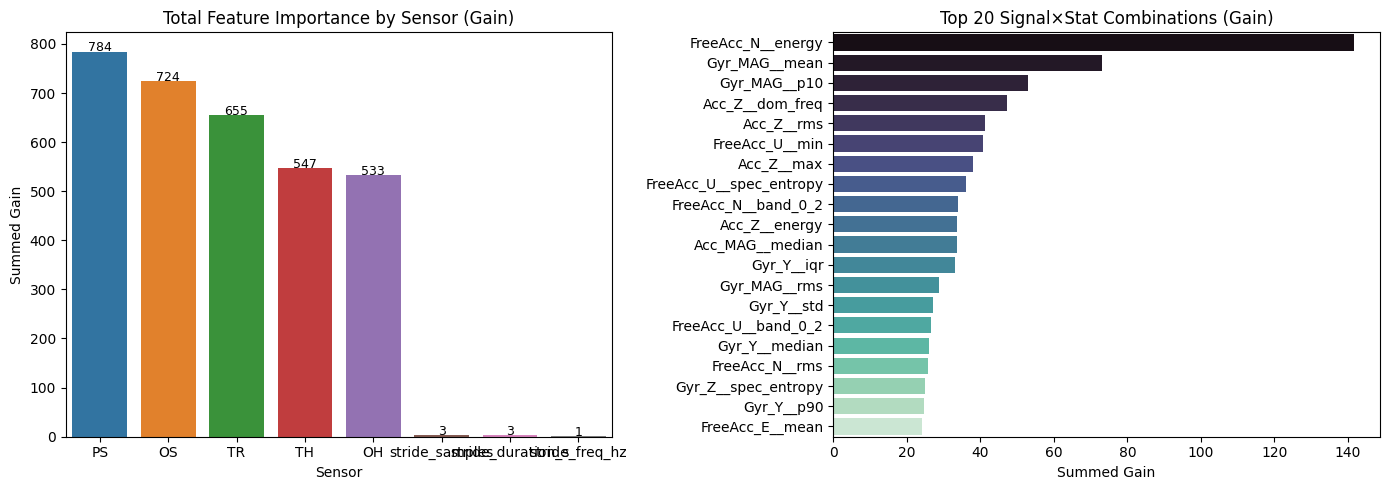

In [19]:
fi_gain = fi_dfs["gain"].copy()
fi_gain["sensor"] = fi_gain["feature_name"].str.split("__").str[0]
sensor_importance = (fi_gain.groupby("sensor")["importance"]
                             .sum()
                             .sort_values(ascending=False)
                             .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=sensor_importance, x="sensor", y="importance",
            palette="tab10", ax=axes[0])
axes[0].set_title("Total Feature Importance by Sensor (Gain)")
axes[0].set_ylabel("Summed Gain")
axes[0].set_xlabel("Sensor")
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f"{bar.get_height():.0f}", ha="center", fontsize=9)

fi_gain["signal_stat"] = fi_gain["feature_name"].str.split("__", n=1).str[1]
signal_importance = (fi_gain.groupby("signal_stat")["importance"]
                             .sum()
                             .sort_values(ascending=False)
                             .head(20)
                             .reset_index())
sns.barplot(data=signal_importance, y="signal_stat", x="importance",
            palette="mako", ax=axes[1])
axes[1].set_title("Top 20 Signal×Stat Combinations (Gain)")
axes[1].set_ylabel("")
axes[1].set_xlabel("Summed Gain")

plt.tight_layout()
plt.savefig(WORK_ROOT / "feature_importance_by_sensor.png", dpi=150, bbox_inches="tight")
plt.show()


## Summary Report

In [20]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1_per_class, support = precision_recall_fscore_support(
    y, xgb_preds, labels=range(len(class_names)))

acc  = accuracy_score(y, xgb_preds)
bacc = balanced_accuracy_score(y, xgb_preds)
mf1  = f1_score(y, xgb_preds, average="macro")
wf1  = f1_score(y, xgb_preds, average="weighted")

border = "═" * 60
print(border)
print("SUMMARY REPORT")
print(border)
print(f"  Dataset      : {len(y):,} strides  |  {len(class_names)} terrain classes")
print(f"  Participants : {n_participants}")
print(f"  Features     : {X.shape[1]}")
print(f"  CV strategy  : StratifiedGroupKFold (leave-participant-out)")
print()
print("Overall Performance")
print(f"  Accuracy          : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Balanced Accuracy : {bacc:.4f}")
print(f"  Macro F1          : {mf1:.4f}")
print(f"  Weighted F1       : {wf1:.4f}")
print()
print("Per-Class")
header = f"  {'Class':<20} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}"
print(header)
print("  " + "─" * (len(header) - 2))
for i, cn in enumerate(class_names):
    print(f"  {cn:<20} {precision[i]:>10.4f} {recall[i]:>10.4f} {f1_per_class[i]:>10.4f} {support[i]:>10}")
print()
print("CV Fold Summary")
print(f"  Mean Acc    : {fold_df['accuracy'].mean():.4f} ± {fold_df['accuracy'].std():.4f}")
print(f"  Mean BalAcc : {fold_df['balanced_acc'].mean():.4f} ± {fold_df['balanced_acc'].std():.4f}")
print(f"  Mean MacroF1: {fold_df['macro_f1'].mean():.4f} ± {fold_df['macro_f1'].std():.4f}")
print()
print("Top-5 Most Important Features (Gain)")
for _, row in fi_dfs["gain"].head(5).iterrows():
    print(f"  {row['feature_name']:<45} {row['importance']:>10.2f}")
print(border)

# save to JSON
report = {
    "overall": {"accuracy": float(acc), "balanced_acc": float(bacc),
                "macro_f1": float(mf1), "weighted_f1": float(wf1)},
    "per_class": {cn: {"precision": float(precision[i]), "recall": float(recall[i]),
                       "f1": float(f1_per_class[i]), "support": int(support[i])}
                  for i, cn in enumerate(class_names)},
    "cv_folds": fold_df.to_dict(orient="records"),
    "top10_features_gain": fi_dfs["gain"].head(10)[["feature_name","importance"]].to_dict(orient="records"),
}
import json
with open(WORK_ROOT / "summary_report.json", "w") as fp:
    json.dump(report, fp, indent=2)

════════════════════════════════════════════════════════════
SUMMARY REPORT
════════════════════════════════════════════════════════════
  Dataset      : 8,847 strides  |  7 terrain classes
  Participants : 21
  Features     : 1263
  CV strategy  : StratifiedGroupKFold (leave-participant-out)

Overall Performance
  Accuracy          : 0.5606  (56.06%)
  Balanced Accuracy : 0.5347
  Macro F1          : 0.5340
  Weighted F1       : 0.5466

Per-Class
  Class                 Precision     Recall         F1    Support
  ────────────────────────────────────────────────────────────────
  Flat                     0.5610     0.7046     0.6246       2292
  Grass                    0.3442     0.2419     0.2841        959
  Stairs                   0.6758     0.8270     0.7438       1318
  Slope Ascent             0.5668     0.4516     0.5027        930
  Slope Descent            0.5000     0.6021     0.5463       1038
  Gravel                   0.4635     0.3147     0.3749       1433
  Uneven Ter

## Model Export

terrain_model.ubj | preprocessor.pkl | model_meta.json

In [21]:
import pickle, json
from pathlib import Path

EXPORT_DIR = WORK_ROOT / "model_export"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# model weights 
model_path = EXPORT_DIR / "terrain_model.ubj"
final_clf.save_model(str(model_path))
print(f"model saved  --> {model_path}")

# imputer + RobustScaler
prep_path = EXPORT_DIR / "preprocessor.pkl"
with open(prep_path, "wb") as fp:
    pickle.dump(preprocessor, fp)
print(f"preprocessor saved to {prep_path}")

# metadata --> feature names, label map, constants
meta = {
    "feature_columns": feat_cols,
    "label_encoder": {
        str(int(code)): name
        for code, name in zip(le.classes_, class_names)},
    "terrain_names": {str(k): v for k, v in active_terrain_names.items()},

    "constants": {
        "FS": FS,
        "LOWPASS_CUTOFF": LOWPASS_CUTOFF,
        "FILTER_ORDER": FILTER_ORDER,
        "MIN_STRIDE_SAMPLES": MIN_STRIDE_SAMPLES,
        "MAX_STRIDE_SAMPLES": MAX_STRIDE_SAMPLES,
        "TERRAIN_PURITY_THRESH": TERRAIN_PURITY_THRESH,
        "MERGE_STAIRS": MERGE_STAIRS,
        "PRIMARY_SENSOR": PRIMARY_SENSOR,
    },

    # which sensors and signal columns the feature extractor uses
    "all_sensors": list(ALL_SENSORS),
    "signal_columns": list(SIGNAL_COLUMNS),
    "optional_cols": list(OPTIONAL_COLS),
    "feature_signals": list(FEATURE_SIGNALS),
}

meta_path = EXPORT_DIR / "model_meta.json"
with open(meta_path, "w") as fp:
    json.dump(meta, fp, indent=2)
print(f"Metadata savedd to --> {meta_path}")

print(f"\nExport complete")

model saved  --> /kaggle/working/imu_terrain_outputs/model_export/terrain_model.ubj
preprocessor saved to /kaggle/working/imu_terrain_outputs/model_export/preprocessor.pkl
Metadata savedd to --> /kaggle/working/imu_terrain_outputs/model_export/model_meta.json

Export complete
